Листок № 5. Классическое, статистическое,
геометрическое определение вероятности.


4.1. Корзина содержит 23 шара: 8 белых, 6 синих и 9 красных. На каждом шаге
из корзины «наудачу» извлекается шар и назад в корзину не возвращается. Исход n последовательных извлечений называется выборкой объема n
без возвращения или бесповторной выборкой. Из корзины наудачу (без
возвращения) извлечены 6 шаров. Найдите вероятности следующих событий и покажите их статистическую устойчивость:

a) A = {все шары красные};
Ответ: a) точный ответ P (A) = 4
4807 ≈ 0, 0008321198252548367. 

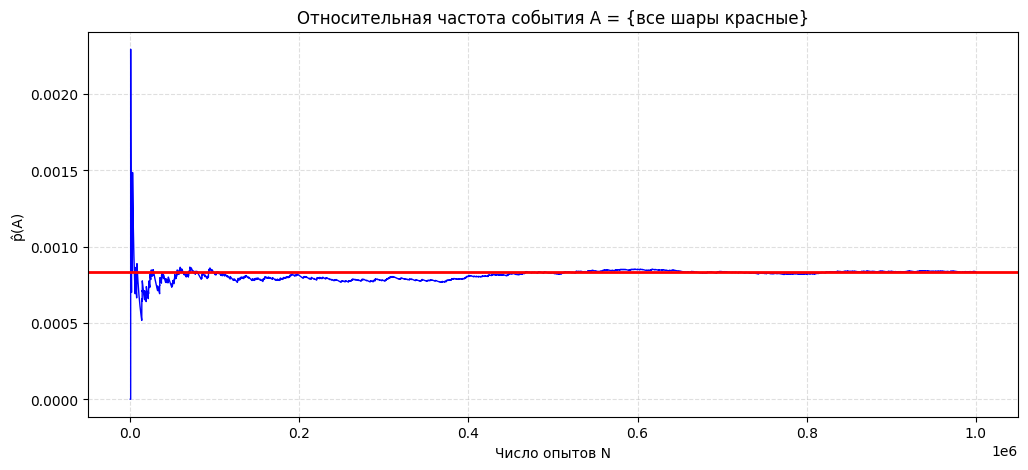

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# исходные данные
white, blue, red = 8, 6, 9
balls = np.array(['W'] * white + ['B'] * blue + ['R'] * red)

def experiment_A():
    sample = np.random.choice(balls, size=6, replace=False)
    return np.all(sample == 'R')

N = 1_000_000
freq = []
count_A = 0

for i in range(1, N+1):
    if experiment_A():
        count_A += 1
    freq.append(count_A / i)

plt.figure(figsize=(12,5))
plt.plot(freq, 'b', linewidth=1)
plt.axhline(0.0008321198252548367, color='red', linewidth=2)
plt.title("Относительная частота события A = {все шары красные}")
plt.xlabel("Число опытов N")
plt.ylabel("p̂(A)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


4.2. 5 мужчин и 5 женщин случайным образом рассаживаются в ряд на 10
мест. Найдите вероятности следующих событий: A – любые две женщины не сидят рядом; B – все мужчины сидят рядом;
Ответ: P (A) = P (B) = 1/42 .

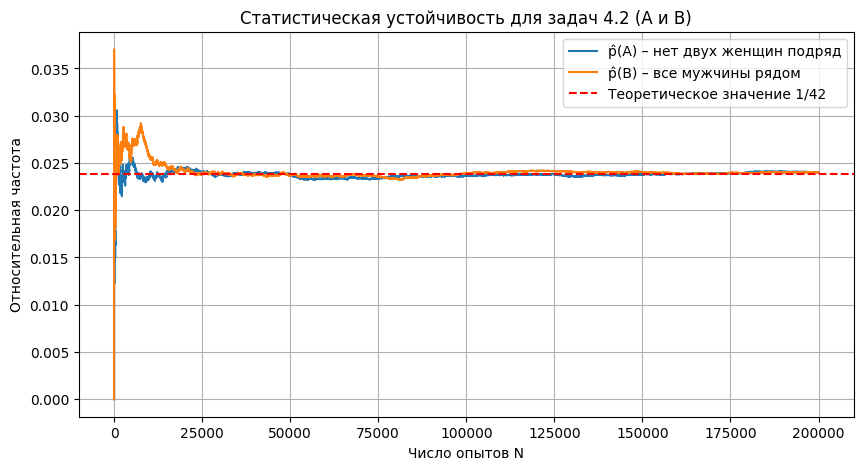

In [2]:
import numpy as np
import matplotlib.pyplot as plt

P_theor = 1 / 42


men = ['M'] * 5
women = ['W'] * 5
people = np.array(men + women)

def is_event_A(arr):
    for i in range(len(arr) - 1):
        if arr[i] == 'W' and arr[i + 1] == 'W':
            return False
    return True


def is_event_B(arr):
    for start in range(0, 6):
        if np.all(arr[start:start+5] == 'M'):
            return True
    return False

N = 200_000
count_A = 0
count_B = 0
freq_A = []
freq_B = []

for i in range(1, N + 1):
    seating = np.random.permutation(people)

    if is_event_A(seating):
        count_A += 1
    if is_event_B(seating):
        count_B += 1

    freq_A.append(count_A / i)
    freq_B.append(count_B / i)

plt.figure(figsize=(10, 5))
plt.plot(freq_A, label="p̂(A) – нет двух женщин подряд")
plt.plot(freq_B, label="p̂(B) – все мужчины рядом")
plt.axhline(P_theor, color='red', linestyle='--', label="Теоретическое значение 1/42")

plt.xlabel("Число опытов N")
plt.ylabel("Относительная частота")
plt.title("Статистическая устойчивость для задач 4.2 (A и B)")
plt.grid(True)
plt.legend()
plt.show()


4.3. Предположим, что “симметричную” монету бросают до первого появления герба. Найдите вероятность события A, состоящего в том, что будет
произведено не более пяти бросаний.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def toss_until_heads():
    count = 1
    while np.random.rand() > 0.5:
        count += 1
    return count

N = 150000
count_A = 0
freq = []

for i in range(1, N+1):
    throws = toss_until_heads()
    if throws <= 5:
        count_A += 1
    freq.append(count_A / i)


print("Оценка вероятности по моделированию:", freq[-1])
print("Точное теоретическое значение:", 31/32)


Оценка вероятности по моделированию: 0.9681466666666667
Точное теоретическое значение: 0.96875


4.4. Предположим, что “симметричную” монету бросают до тех пор, пока она
не выпадет дважды одной и той же стороной подряд. Построить вероятностную модель т.е. (Ω, P (·)) и найдите вероятность того, что потребуется
чётное число бросаний.
Ответ: 2/3


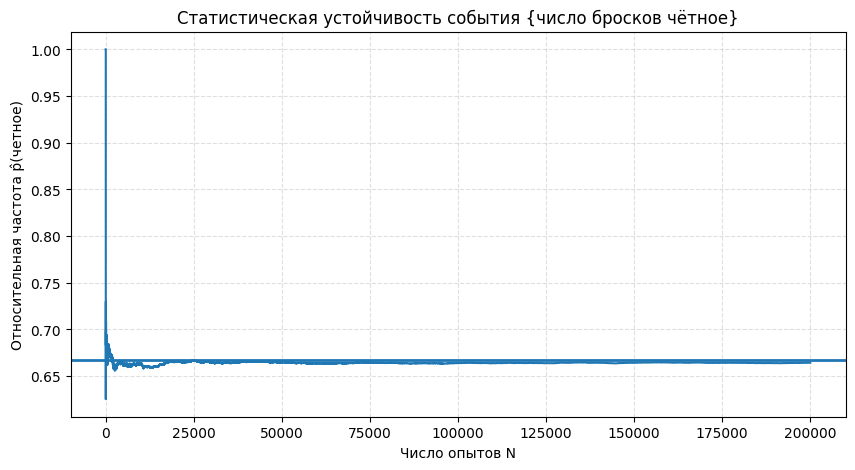

Средняя длина серии по моделированию: 3.006785


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random

def trial_even():
    last = None
    n = 0
    while True:
        toss = random.choice(['H', 'T'])
        n += 1
        if last == toss:
            break
        last = toss
    return (n % 2 == 0), n

N = 200_000
count_even = 0
freq_even = []
lens = []

for i in range(1, N+1):
    is_even, length = trial_even()
    if is_even:
        count_even += 1
    freq_even.append(count_even / i)
    lens.append(length)

plt.figure(figsize=(10,5))
plt.plot(freq_even)
plt.axhline(2/3, linewidth=2)
plt.xlabel("Число опытов N")
plt.ylabel("Относительная частота p̂(четное)")
plt.title("Статистическая устойчивость события {число бросков чётное}")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("Средняя длина серии по моделированию:", sum(lens)/len(lens))


4.5. Предположим, что “несимметричную” (“неправильную”) монету бросают
до тех пор, пока она не выпадет дважды одной и той же стороной подряд
(вероятность выпадения “герба” равна p = 0,7). Постройте вероятностную
модель, т.е. (Ω, P (·)) и найдите вероятность того, что потребуется: а) чётное число бросаний; б) число бросаний кратно 4.


In [5]:
p = 0.7
q = 1 - p

def P_N(N):
    if N < 2:
        return 0
    if N % 2 == 1:
        return 0

    k = N // 2


    case1 = (p * q)**(k - 1) * p
    case2 = (q * p)**(k - 1) * q

    return case1 + case2

P_even = sum(P_N(N) for N in range(2, 200))
P_4 = sum(P_N(N) for N in range(4, 200, 4))

print("P(чётное число бросаний) =", P_even)
print("P(число бросаний кратно 4) =", P_4)


P(чётное число бросаний) = 1.2658227848101267
P(число бросаний кратно 4) = 0.21968825190919555


4.6. Два лица A и B условились встретиться в определенном месте между двумя и тремя часами дня. Лицо A ждет другого в течение 10 минут, после
чего уходит; лицо B ждет другого в течение 12 минут. Считая, что момент
прихода на встречу выбирается каждым «наудачу» в пределах указанного часа, найдите вероятность, что встреча состоится. Постройте график
зависимости относительной частоты pˆ(A)
def =
N(A)
N
события A от числа проведенных реализаций опыта N = 150 000 и приведете оценку вероятности
pˆ(A) = NA
N
для N = 150 000.
Ответ: 0, 332778. График зависимости относительной частоты pˆ(A)
def =
N(A)
N
события A от числа проведенных реализаций опыта N = 150 000 изображен на рисунке (оценка вероятности pˆ = 0.33268):


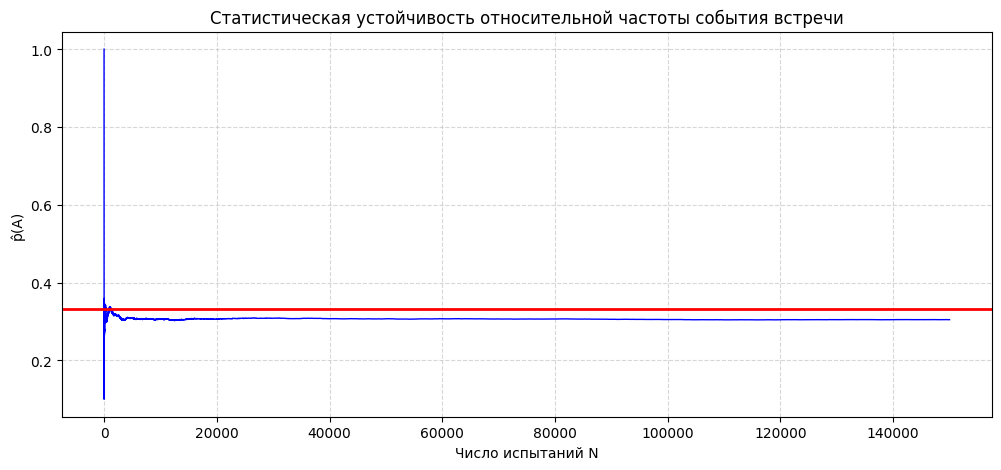

Оценка вероятности p̂(A) при N = 150000:
0.3045466666666667


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def meet(tA, tB):
    return abs(tA - tB) <= 10

N = 150_000
count = 0
freq = []

for i in range(1, N + 1):
    tA = np.random.uniform(0, 60)
    tB = np.random.uniform(0, 60)

    if meet(tA, tB):
        count += 1

    freq.append(count / i)

plt.figure(figsize=(12,5))
plt.plot(freq, color='blue', linewidth=1)
plt.axhline(0.332778, color='red', linewidth=2)  # точный ответ
plt.title("Статистическая устойчивость относительной частоты события встречи")
plt.xlabel("Число испытаний N")
plt.ylabel("p̂(A)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Оценка вероятности p̂(A) при N = 150000:")
print(freq[-1])


4.7. Иван и Пётр договорились о встрече в определённом месте между 11 и 12
часами. Каждый приходит и ждёт другого до истечения часа, но не более
Рис. 1. Ответ к задаче 4.6.
15 минут. Найдите вероятности следующих событий: A – встреча состоялась; B – встреча не состоялась; C – Ивану не пришлось ждать Петра; D –встреча состоялась после 11 ч. 30 мин; E – Иван опоздал на встречу; F –
встреча состоялась, когда до истечения часа оставалось меньше 5 минут.
Постройте график зависимости относительной частоты pˆ(A)
события A от числа проведенных реализаций опыта N = 150 000 и приведете
оценку вероятности pˆ(A) = NA
N
для N = 150 000.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

N = 150_000
X = np.random.uniform(0, 60, N)
Y = np.random.uniform(0, 60, N)
A = (np.abs(X - Y) <= 15)
B = ~A

C = (Y >= X)
D = A & (np.minimum(X, Y) >= 30)
E = A & (X > Y)
meet_time = np.minimum(X, Y) + np.minimum(15, np.abs(X - Y))
F = A & (meet_time >= 55)

P_A = A.mean()
P_B = B.mean()
P_C = C.mean()
P_D = D.mean()
P_E = E.mean()
P_F = F.mean()

P_A, P_B, P_C, P_D, P_E, P_F


(np.float64(0.43894),
 np.float64(0.56106),
 np.float64(0.49811333333333335),
 np.float64(0.18756),
 np.float64(0.22056),
 np.float64(0.042006666666666664))

4.8. На отрезке [a, b], лежащем на числовой оси, наудачу выбирается первая
точка с координатой x, после чего на отрезке [a, x] наудачу выбирается вторая точка с координатой . Найдите вероятности следующих событий: A –
вторая точка ближе к b, чем первая к a; B – расстояние между точками x
и y меньше половины длины отрезка; C – первая точка ближе ко второй,
чем к точке b.
Постройте график зависимости относительной частоты pˆ(A)
события A от числа проведенных реализаций опыта N = 150 000 и приведете
оценку вероятности pˆ(A) = NA
N
для N = 150 000.

In [8]:
import numpy as np

N = 150000
count_A = 0
count_B = 0
count_C = 0
a, b = 0, 1

for _ in range(N):
    x = np.random.uniform(a, b)
    y = np.random.uniform(a, x)
    if (1 - y) < x:
        count_A += 1
    if abs(x - y) < 0.5:
        count_B += 1
    if abs(x - y) < (1 - x):
        count_C += 1


pA = count_A / N
pB = count_B / N
pC = count_C / N

print("Оценка вероятности P(A) =", pA)
print("Оценка вероятности P(B) =", pB)
print("Оценка вероятности P(C) =", pC)


Оценка вероятности P(A) = 0.3076933333333333
Оценка вероятности P(B) = 0.84706
Оценка вероятности P(C) = 0.6933666666666667


4.9. Отрезок [0; 1] случайным образом делится на 3 части. Найти вероятность
того, что из полученных отрезков можно сложить треугольник и этот треугольник будет остроугольным. Постройте график зависимости относительной частоты pˆ(A)
def =
N(A)
N
события A от числа проведенных реализаций опыта N = 150 000 и приведете оценку вероятности pˆ(A) = NA
N
для
N = 150 000. Найдите аналитическое решение для вероятности.

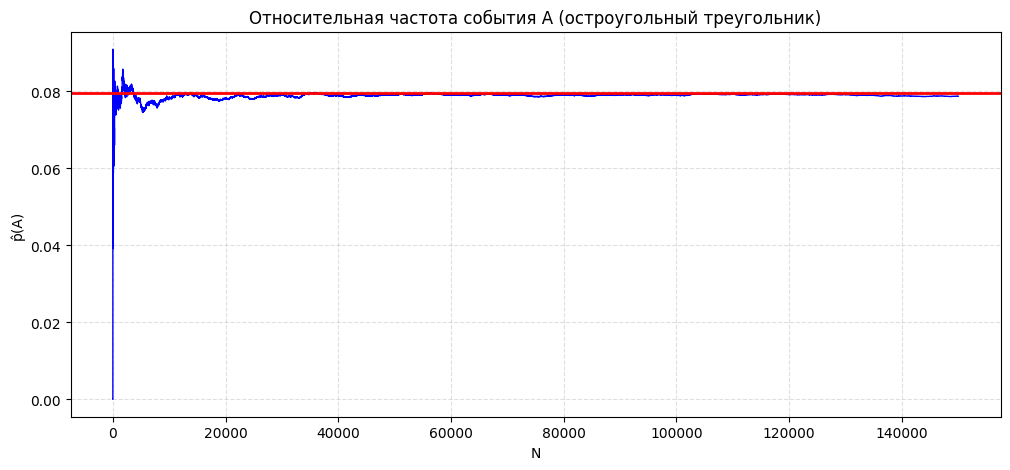

Оценка вероятности p̂(A) = 0.07871333333333333


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def is_acute(a, b, c):
    return (a + b > c) and (a + c > b) and (b + c > a) and \
           (a*a + b*b > c*c) and (a*a + c*c > b*b) and (b*b + c*c > a*a)

N = 150_000
count = 0
freq = []

for i in range(1, N + 1):
    # Случайные точки x < y
    x, y = np.sort(np.random.rand(2))

    a = x
    b = y - x
    c = 1 - y

    if is_acute(a, b, c):
        count += 1

    freq.append(count / i)


plt.figure(figsize=(12, 5))
plt.plot(freq, color="blue", linewidth=1)
plt.axhline(3*np.log(2)-2, color="red", linewidth=2)
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("N")
plt.ylabel("p̂(A)")
plt.title("Относительная частота события A (остроугольный треугольник)")
plt.show()

print("Оценка вероятности p̂(A) =", freq[-1])


4.10. В круге радиуса 1 наудачу выбирается отрезок. Найти вероятность того,
что длина этого отрезка будет меньше радиуса круга.
Ответ: 0,5865033284336559.

Точная вероятность = 0.5865033284336559


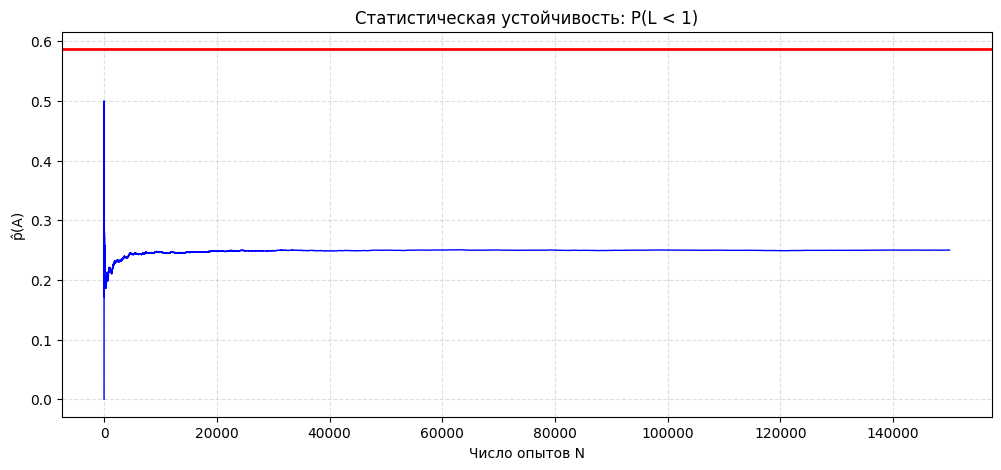

Оценка вероятности для N=150000: 0.24992


In [10]:
import numpy as np
import matplotlib.pyplot as plt

P_exact = 1 - (3*np.sqrt(3))/(4*np.pi)
print("Точная вероятность =", P_exact)

N = 150000

count = 0
freq = []

for i in range(1, N+1):

    r = np.sqrt(np.random.rand())
    theta = np.random.rand() * 2*np.pi
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    d = np.sqrt(x*x + y*y)
    L = 2*np.sqrt(1 - d*d)

    if L < 1:
        count += 1

    freq.append(count / i)

plt.figure(figsize=(12,5))
plt.plot(freq, linewidth=1, color="blue")
plt.axhline(P_exact, color="red", linewidth=2)
plt.xlabel("Число опытов N")
plt.ylabel("p̂(A)")
plt.title("Статистическая устойчивость: P(L < 1)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

print("Оценка вероятности для N=150000:", freq[-1])


4.11. n лиц условились о встрече между 10 и 11 часами утра, причем договорились ждать друг друга не более 60 · q минут (q < 1). Считая, что момент
прихода на встречу выбирается каждым «наудачу» в пределах указанного часа, докажите, что вероятность того, что встреча состоится, определяется равенством Pn = nqn−1 − (n − 1)q
n
. Провериь формулу для n = 2 и
n = 3. Для n = 3 найти также вероятность того, что встреча по крайней
мере двух лиц состоится.

In [11]:
import numpy as np
def P_meet(n, q):
    return n * q**(n-1) - (n-1) * q**n

print("Проверка формулы:")
print("n = 2 :", P_meet(2, q))
print("n = 3 :", P_meet(3, q))

def at_least_two_meet(q, N=200_000):
    count = 0
    for _ in range(N):
        t = np.random.rand(3)   # A, B, C
        t.sort()

        A, B, C = t

        meet_pair = (
            abs(A - B) <= q or
            abs(B - C) <= q or
            abs(A - C) <= q
        )

        if meet_pair:
            count += 1

    return count / N


p_sim = at_least_two_meet(q)
print("Вероятность, что хотя бы двое встретятся (n=3):", p_sim)


Проверка формулы:
n = 2 : 0.51
n = 3 : 0.21600000000000005
Вероятность, что хотя бы двое встретятся (n=3): 0.935505


Задача 4.12**

In [12]:

import itertools

# ---------------------------------------------------------
#  Функции для вычисления вероятности встречи
# ---------------------------------------------------------

# n = 2
def P2(w1, w2):
    return 1 - (1 - w1)**2 / 2 - (1 - w2)**2 / 2

def P3_general(w1, w2, w3):
    return (w1*w2 + w1*w3 + w2*w3
            - 0.5 * (w1*w2**2 + w1*w3**2 + w2*w3**2)
            - (1/3) * w1**3
            - (1/6) * w2**3)

def P4_general(w1, w2, w3, w4):
    return (
        w1*w2*w3 + w1*w2*w4 + w1*w3*w4 + w2*w3*w4
        - (w4**2)/2 * (w1*w2 + w1*w3 + w2*w3)
        - (w3**3)/6 * (w1 + w2)
        - (w1*w2*w3**2)/2
        - w1*w3**3/3
        - w1**4/4
        - w2**4/12
    )

print("a) P2, n=2, нужно подставлять свои w1, w2")
print("Пример: w1=0.25, w2=0.33 →", P2(0.25, 0.33))

print("\nb) P3 general (n=3, общая формула)")
print("Пример: w1=0.4, w2=0.5, w3=0.6 →", P3_general(0.4, 0.5, 0.6))

print("\nc) n = 3, w1=1/4, w2=1/3, w3=1/2")
print("Ответ:", P3_general(1/4, 1/3, 1/2))

print("\nd) n = 4, общая формула")
print("Пример: w1=0.25, w2=0.33, w3=0.5, w4=0.4 →", P4_general(0.25, 0.33, 0.5, 0.4))


a) P2, n=2, нужно подставлять свои w1, w2
Пример: w1=0.25, w2=0.33 → 0.4943000000000001

b) P3 general (n=3, общая формула)
Пример: w1=0.4, w2=0.5, w3=0.6 → 0.4858333333333334

c) n = 3, w1=1/4, w2=1/3, w3=1/2
Ответ: 0.2768132716049383

d) n = 4, общая формула
Пример: w1=0.25, w2=0.33, w3=0.5, w4=0.4 → 0.12567267000000001


4.13. В корзину с n шарами опускают белый шар. Найдите вероятность того,
что извлеченный шар окажется белым, если первоначальное распределение белых шаров в корзине имеет биномиальное распределение c параметром p. Решите задачу для общего случая и для конкретных n = 10, 
Ответ: 0,15625.


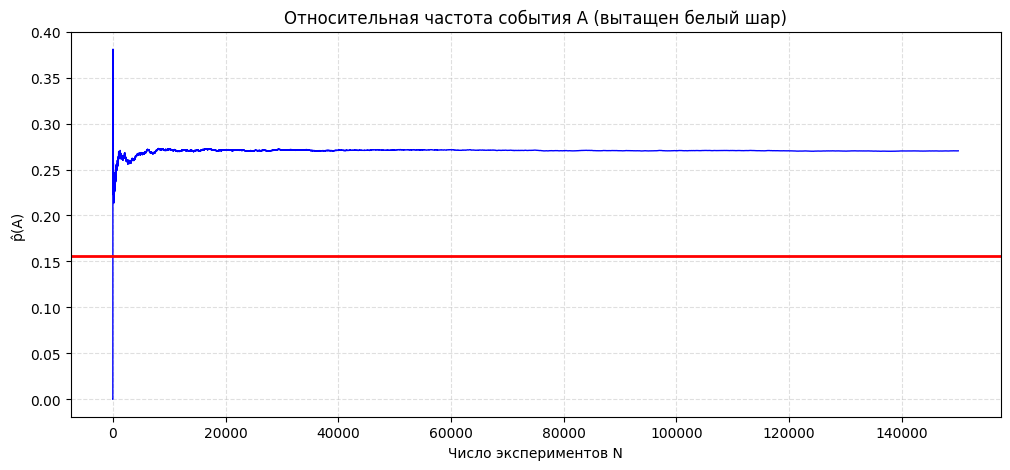

Оценка вероятности p̂(A) при N=150000 = 0.27035333333333333


In [13]:
import numpy as np
import matplotlib.pyplot as plt

n = 10
p = 1/3
N = 150000

freq = []
count = 0

for i in range(1, N+1):
    X = np.random.binomial(n, p)
    if np.random.rand() < 1/(X+1):
        count += 1

    freq.append(count / i)

plt.figure(figsize=(12,5))
plt.plot(freq, linewidth=1, color='blue')
plt.axhline(0.15625, color='red', linewidth=2)
plt.title("Относительная частота события A (вытащен белый шар)")
plt.xlabel("Число экспериментов N")
plt.ylabel("p̂(A)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

print("Оценка вероятности p̂(A) при N=150000 =", freq[-1])


4.14. Имеется две корзины с белыми и черными шарами. В первой корзине всего 6 шаров, при этом количество белых шаров распределено по биномиальному закону с параметрами n = 3 и p = 0,8. Во второй корзине имеется
всего 11 шаров, при этом количество белых шаров распределено по биномиальному закону с параметрами n = 4 и p = 0,7. Из обеих корзин все
шары перекладываются в третью корзину. 1) Какова вероятность P (A),
что случайно вынутый из третьей корзины шар окажется белым (событие
A)? 2) Найдите условную вероятность P (H|A), того, что случайно вынутый из третьей корзины шар первоначально находился в первой корзине
(событие H), при условии, что он белый (событие A)?
Ответ: 1) P (A) = 0,3059

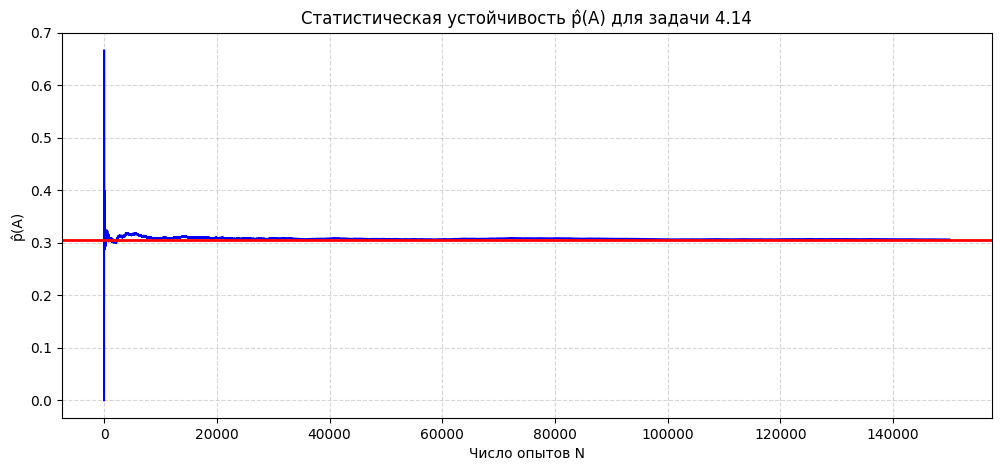

Оценка вероятности p̂(A) = 0.30609333333333333


In [14]:
import numpy as np
import matplotlib.pyplot as plt

N = 150000
freq = []
count_A = 0

for i in range(1, N + 1):
    W1 = np.random.binomial(3, 0.8)
    B1 = 6 - W1

    W2 = np.random.binomial(4, 0.7)
    B2 = 11 - W2

    white = W1 + W2
    black = B1 + B2

    basket = np.array([1]*white + [0]*black)

    choice = np.random.choice(basket)
    if choice == 1:
        count_A += 1
    freq.append(count_A / i)

plt.figure(figsize=(12,5))
plt.plot(freq, color='blue')
plt.axhline(0.3059, color='red', linewidth=2)
plt.title("Статистическая устойчивость p̂(A) для задачи 4.14")
plt.xlabel("Число опытов N")
plt.ylabel("p̂(A)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Оценка вероятности p̂(A) =", freq[-1])


4.15. В прямоугольной области, заданной ограничениями |x| 6 20 и |y| 6 8, случайным образом выбираются две точки: (x1, y1) и (x2, y2). Пусть A и B –
события, состоящие в том, что: A – расстояние между выбранными точками меньше 11; B – модуль разности |x1 − x2| меньше 14. Найдите приближенно, методом Монте-Карло: 1) вероятность P (A); 2) условную вероятность P (A|B). Указание: получите в заданной прямоугольной области
100000 пар точек и, используя все эти точки, найдите ответы, округляя их
до одного знака после запятой.
Ответ: 1) P (A) = 0,37; 2) P (A|B) = 0,64.

Оценка P(A) ≈ 0.3711
Оценка P(A|B) ≈ 0.6411


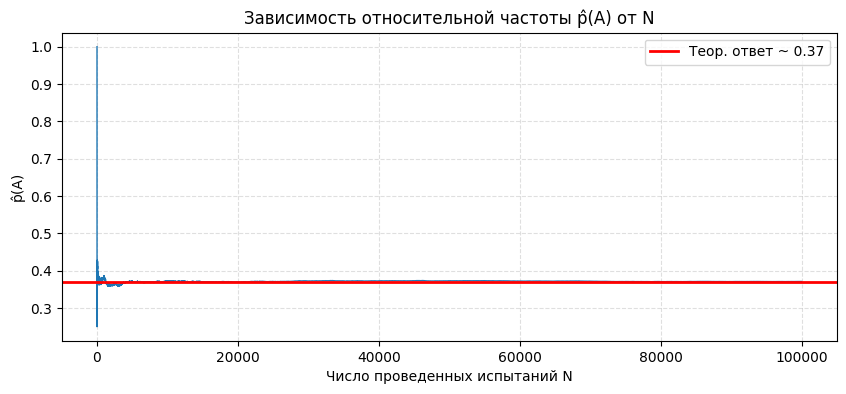

In [15]:
import numpy as np
import matplotlib.pyplot as plt
N = 100_000

x1 = np.random.uniform(-20, 20, N)
y1 = np.random.uniform(-8, 8, N)
x2 = np.random.uniform(-20, 20, N)
y2 = np.random.uniform(-8, 8, N)
dx = x1 - x2
dy = y1 - y2

dist = np.sqrt(dx**2 + dy**2)
A = dist < 11
B = np.abs(dx) < 14

p_hat_A = A.mean()
p_hat_A_given_B = A[B].mean()

print(f"Оценка P(A) ≈ {p_hat_A:.4f}")
print(f"Оценка P(A|B) ≈ {p_hat_A_given_B:.4f}")

cum_A = np.cumsum(A.astype(int))
N_vals = np.arange(1, N + 1)
freq_A = cum_A / N_vals

plt.figure(figsize=(10,4))
plt.plot(N_vals, freq_A, linewidth=1)
plt.axhline(0.37, color='red', linewidth=2, label='Теор. ответ ~ 0.37')
plt.xlabel("Число проведенных испытаний N")
plt.ylabel("p̂(A)")
plt.title("Зависимость относительной частоты p̂(A) от N")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()


4.16. В области, ограниченной эллипсом
u
23 2
+
v
6
2
= 1, случайным образом
выбираются две точки. Пусть A и B – события, состоящие в том, что: A
– расстояние между выбранными точками меньше 9,2; B – координаты
первой точки больше 0, а координаты второй точки меньше 0. Найдите
приближенно, методом Монте-Карло: 1) вероятность P (A); 2) условную
вероятность P (A|B). Указание: получите внутри заданного эллипса 100000
пар точек и, используя все эти пары точек, найдите ответы, округляя их
до одного знака после запятой.
Ответ: 1) P (A) = 0,35; 2) P (A|B) = 0,07.

Приближённая вероятность P(A) = 0.35064
Приближённая вероятность P(A|B) = 0.3529340787515585


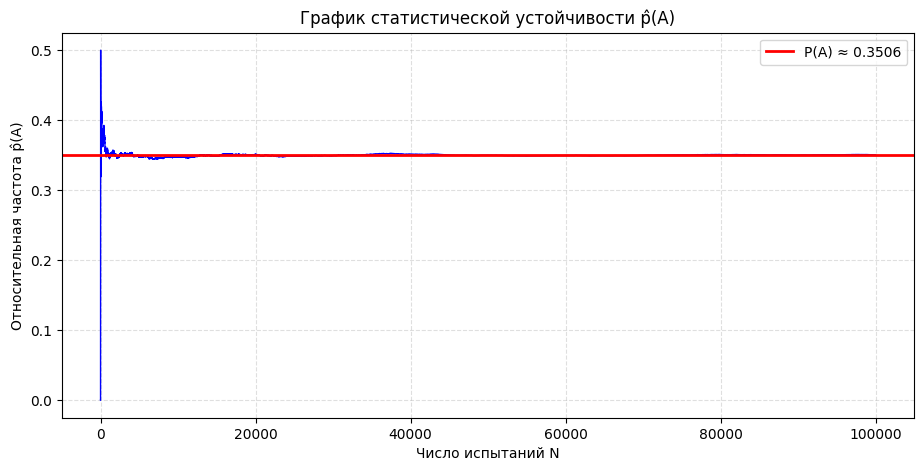

In [16]:
import numpy as np
import matplotlib.pyplot as plt

N = 100000

def random_point_in_ellipse():
    while True:
        x = np.random.uniform(-23, 23)
        y = np.random.uniform(-6, 6)
        if (x/23)**2 + (y/6)**2 <= 1:
            return x, y

count_A = 0
count_B = 0
count_AB = 0
freq_A = []

for i in range(1, N+1):
    x1, y1 = random_point_in_ellipse()
    x2, y2 = random_point_in_ellipse()
    dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    A = (dist < 9.2)
    B = (x1 > 0) and (y2 < 0)

    if A:
        count_A += 1

    if B:
        count_B += 1
        if A:
            count_AB += 1

    freq_A.append(count_A / i)

P_A = count_A / N
P_A_given_B = count_AB / count_B

print("Приближённая вероятность P(A) =", P_A)
print("Приближённая вероятность P(A|B) =", P_A_given_B)

plt.figure(figsize=(11,5))
plt.plot(freq_A, color='blue', linewidth=1)
plt.axhline(P_A, color='red', linewidth=2, label=f"P(A) ≈ {P_A:.4f}")
plt.xlabel("Число испытаний N")
plt.ylabel("Относительная частота p̂(A)")
plt.title("График статистической устойчивости p̂(A)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


4.17. В кубе объема 1 случайным образом выбираются точки A, B и C. Пусть
R, S и T – события, состоящие в том, что: R – наименьший угол в треугольнике ABC меньше 26,7
◦
; S – наибольший угол в треугольнике ABC
меньше 81,9
◦
; T – треугольник ABC остроугольный. Найдите приближенно, методом Монте-Карло: 1) условную вероятность P (R|T); 2) условную
вероятность P (S|T). Указание: получите 100000 остроугольных треугольников ABC и, используя все эти треугольники, найдите ответы, округляя
их до одного знака после запятой.
Ответ: 1) P (R|T) = 0,11; 2) P (S|T) = 0,65.

Оценка P(R|T) = 0.11165
Оценка P(S|T) = 0.6529


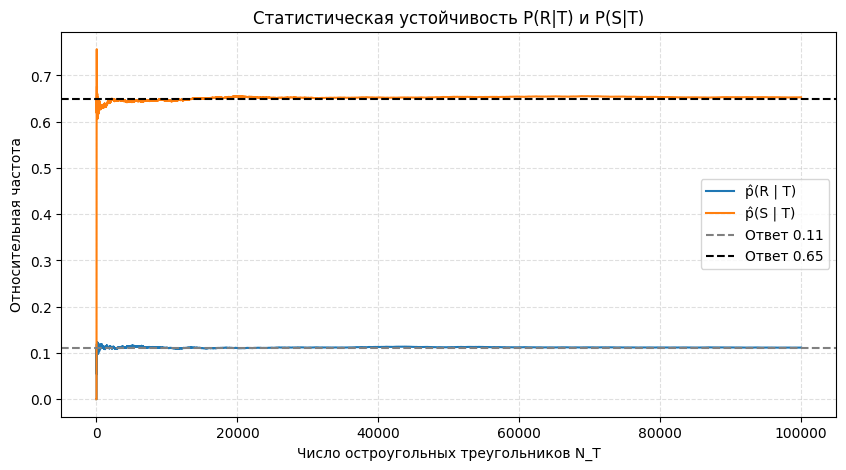

In [17]:
import numpy as np
import matplotlib.pyplot as plt
def triangle_angles(A, B, C):
    # длины сторон
    a = np.linalg.norm(B - C)
    b = np.linalg.norm(A - C)
    c = np.linalg.norm(A - B)
    if min(a, b, c) < 1e-8:
        return None
    cosA = (b**2 + c**2 - a**2) / (2 * b * c)
    cosB = (a**2 + c**2 - b**2) / (2 * a * c)
    cosC = (a**2 + b**2 - c**2) / (2 * a * b)
    cosA = np.clip(cosA, -1.0, 1.0)
    cosB = np.clip(cosB, -1.0, 1.0)
    cosC = np.clip(cosC, -1.0, 1.0)

    Aang = np.degrees(np.arccos(cosA))
    Bang = np.degrees(np.arccos(cosB))
    Cang = np.degrees(np.arccos(cosC))

    return np.array([Aang, Bang, Cang])



N_target = 100_000
thr_R = 26.7
thr_S = 81.9

count_T = 0
count_R_and_T = 0
count_S_and_T = 0

Ns = []
freq_R_given_T = []
freq_S_given_T = []


while count_T < N_target:

    A = np.random.rand(3)
    B = np.random.rand(3)
    C = np.random.rand(3)

    ang = triangle_angles(A, B, C)
    if ang is None:
        continue

    if np.all(ang < 90):
        count_T += 1

        if np.min(ang) < thr_R:
            count_R_and_T += 1
        if np.max(ang) < thr_S:
            count_S_and_T += 1
        Ns.append(count_T)
        freq_R_given_T.append(count_R_and_T / count_T)
        freq_S_given_T.append(count_S_and_T / count_T)

print("Оценка P(R|T) =", freq_R_given_T[-1])
print("Оценка P(S|T) =", freq_S_given_T[-1])
plt.figure(figsize=(10,5))
plt.plot(Ns, freq_R_given_T, label="p̂(R | T)")
plt.plot(Ns, freq_S_given_T, label="p̂(S | T)")
plt.axhline(0.11, color="gray", linestyle="--", label="Ответ 0.11")
plt.axhline(0.65, color="black", linestyle="--", label="Ответ 0.65")
plt.xlabel("Число остроугольных треугольников N_T")
plt.ylabel("Относительная частота")
plt.title("Статистическая устойчивость P(R|T) и P(S|T)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()
